In [ ]:
import pandas as pd
import numpy as np
import glob, os
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 150        # screen quality
plt.rcParams['savefig.dpi'] = 300       # save quality
plt.rcParams['figure.figsize'] = (12, 5)

# ggplot2-like theme
sns.set_theme(
    style='whitegrid',
    font_scale=1.1,
    rc={
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.family': 'sans-serif'
    }
)

ModuleNotFoundError: No module named 'duckdb'

In [ ]:
'''
Please remember to comment out the code after you have a merged file, otherwise, it will keep merging the files and create a new merged file, 
which is not what we want. Also, remember to change the path to your own path, and make sure you have the same file structure as mine, 
otherwise, you may need to change the code a bit. It depends on how you organize your files, I still suggest you to follow the same file structure as mine, 
which is more organised and easier to manage.
'''

path = r'd:\USYD\DATA3888\group_asm\DATA3888G08\Optiver\individual_book_train'
files = glob.glob(os.path.join(path, "*.csv"))
print(files) 


[]


In [ ]:
''' 
These lines of code should be commented out after any of you guys already have a merged file. 
Basically, 126 csv files has been aggregated as week 3's material instruction indicated, the new merged file will contain stock information, WAP, BAS, and
log return.
'''

path = r'd:\USYD\DATA3888\group_asm\DATA3888G08\Optiver\individual_book_train'

conn = duckdb.connect()

df = conn.execute(f"""
    WITH wap_data AS (
        SELECT
            regexp_extract(filename, 'stock_(\\d+)\\.csv', 1)::INT AS stock_id,
            time_id,
            seconds_in_bucket,
            FLOOR(seconds_in_bucket / 30) + 1 AS time_bucket,
            (bid_price1 * ask_size1 + ask_price1 * bid_size1) / 
                (bid_size1 + ask_size1) AS WAP,
            ask_price1 / bid_price1 - 1 AS BidAskSpread
        FROM read_csv_auto('{path}/*.csv', filename=true)
    ),
    log_returns AS (
        SELECT
            stock_id,
            time_id,
            time_bucket,
            WAP,
            BidAskSpread,
            LN(WAP / LAG(WAP) OVER (PARTITION BY stock_id, time_id ORDER BY seconds_in_bucket)) AS log_return
        FROM wap_data
    ),
    volatility AS (
        SELECT
            stock_id,
            time_id,
            time_bucket,
            SQRT(SUM(log_return * log_return)) AS volatility
        FROM log_returns
        WHERE log_return IS NOT NULL
        GROUP BY stock_id, time_id, time_bucket
    ),
    aggregated AS (
        SELECT
            stock_id,
            time_id,
            time_bucket,
            AVG(WAP) AS WAP_mean,
            AVG(BidAskSpread) AS BidAskSpread_mean
        FROM log_returns
        GROUP BY stock_id, time_id, time_bucket
    )
    SELECT
        a.stock_id,
        a.time_id,
        a.time_bucket,
        a.WAP_mean,
        a.BidAskSpread_mean,
        v.volatility
    FROM aggregated a
    JOIN volatility v ON a.stock_id = v.stock_id 
                  AND a.time_id = v.time_id 
                  AND a.time_bucket = v.time_bucket
    ORDER BY a.stock_id, a.time_id, a.time_bucket
""").df()

df.to_csv(r'd:\USYD\DATA3888\group_asm\optiver_aggregated.csv', index=False)
print(df.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(8569870, 6)


In [ ]:
size_mb = os.path.getsize(r'd:\USYD\DATA3888\group_asm\optiver_aggregated.csv') / (1024**2)
print(f"File size: {size_mb:.2f} MB")

#These code help you check if the current file is overloading your memory. In general, It should be fine for now.
df = pd.read_csv(r'd:\USYD\DATA3888\group_asm\optiver_aggregated.csv')
mem_mb = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Shape: {df.shape}")
print(f"RAM usage: {mem_mb:.2f} MB")
print(df.head())

File size: 656.03 MB
Shape: (8998663, 6)
RAM usage: 411.93 MB
   stock_id  time_id  time_bucket  WAP_mean  BidAskSpread_mean  volatility
0         0        5          0.0  1.001434           0.000878    0.001433
1         0        5          1.0  1.001601           0.000957    0.006366
2         0        5          2.0  1.002978           0.000748    0.009511
3         0        5          3.0  1.003786           0.000876    0.011409
4         0        5          4.0  1.004046           0.000873    0.016157


In [ ]:
df.isnull().sum()

stock_id             0
time_id              0
time_bucket          0
WAP_mean             0
BidAskSpread_mean    0
volatility           0
dtype: int64

In [ ]:
print("\n=== Infinite values ===")
print(np.isinf(df[['WAP_mean', 'BidAskSpread_mean', 'volatility']]).sum())



=== Infinite values ===
WAP_mean             0
BidAskSpread_mean    0
volatility           0
dtype: int64


In [ ]:
sns.set_theme(style='whitegrid')  # ggplot-like theme

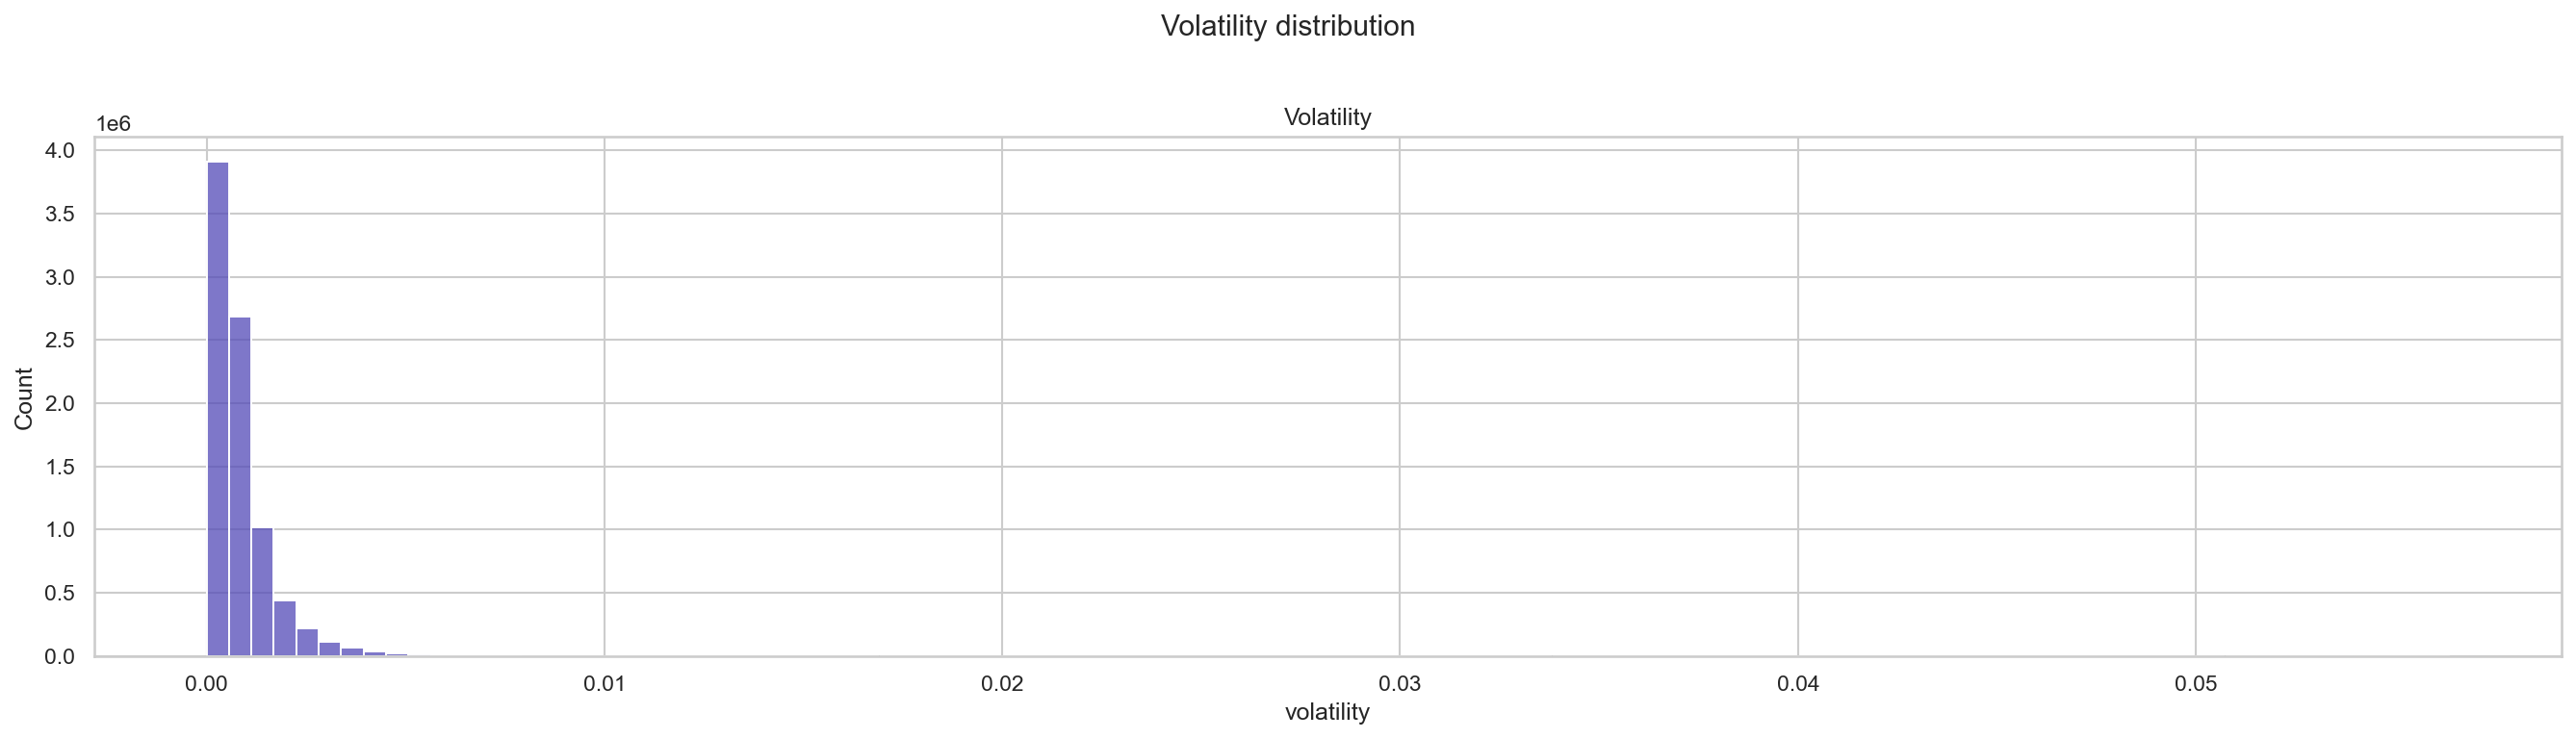

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(18, 5))

sns.histplot(df['volatility'], bins=100, kde=False, color='#534AB7', ax=axes)


axes.set_title('Volatility')
plt.suptitle('Volatility distribution', y=1.02)
plt.tight_layout()
plt.show()



In [ ]:
print(df['volatility'].quantile([0.9, 0.95, 0.99, 0.999, 1.0]))

# How many extreme outliers?
cap = df['volatility'].quantile(0.999)
print(f"Rows above 99.9th percentile: {(df['volatility'] > cap).sum()}")

0.900    0.001782
0.950    0.002425
0.990    0.004305
0.999    0.008384
1.000    0.056371
Name: volatility, dtype: float64
Rows above 99.9th percentile: 8570


In [ ]:
cap_999 = df['volatility'].quantile(0.999)
extreme = df[df['volatility'] > cap_999]
print(f"Number of extreme rows: {len(extreme)}")
print(f"Which stocks: {extreme['stock_id'].value_counts()}")
print(f"Which time_ids: {extreme['time_id'].value_counts().head(10)}")

# Look at the worst offenders
print(df.nlargest(20, 'volatility')[['stock_id', 'time_id', 'time_bucket', 'volatility']])

Number of extreme rows: 8570
Which stocks: stock_id
18     692
27     442
80     423
75     418
103    350
      ... 
113      3
111      2
124      2
50       1
61       1
Name: count, Length: 107, dtype: int64
Which time_ids: time_id
19725    728
30128    431
2956     332
13735    322
3138     288
16839    228
2946     181
15155    171
31170    146
13851    132
Name: count, dtype: int64
         stock_id  time_id  time_bucket  volatility
2073621        30     3138          2.0    0.056371
2073622        30     3138          3.0    0.044110
5327445        78    19725          2.0    0.041162
313402          4     2956          3.0    0.040761
5110674        75    25560          1.0    0.039828
6780944       100    19725          2.0    0.037744
2136366        30    30128          6.0    0.037731
2342827        33    19725         12.0    0.037197
3053367        42    30128          8.0    0.036259
1155796        16     3138          2.0    0.036034
8158139       120    19639          

C:\Users\billc\AppData\Local\Temp\ipykernel_37124\1208005982.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


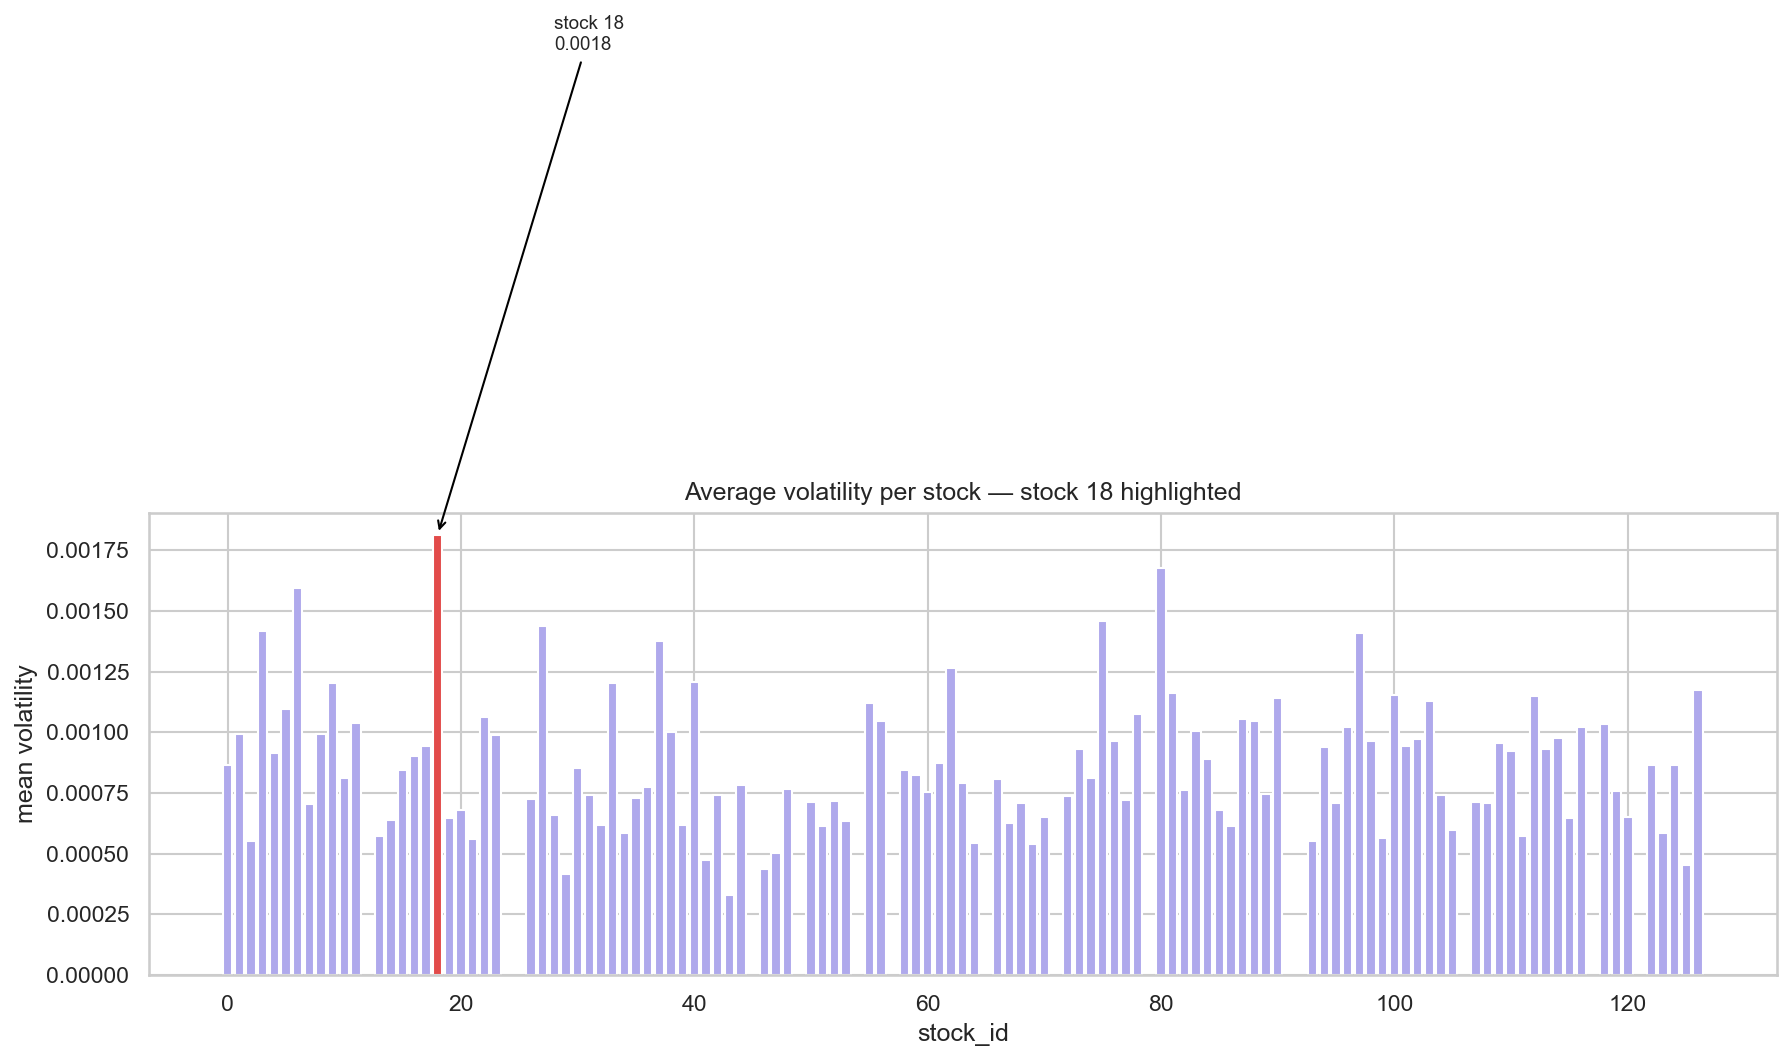

In [ ]:
avg_vol = df.groupby('stock_id')['volatility'].mean().reset_index()

# Create color list manually
colors = ['#E24B4A' if sid == 18 else '#AFA9EC' for sid in avg_vol['stock_id']]

plt.figure(figsize=(14, 4))
sns.set_theme(style='whitegrid')

# Use matplotlib bar directly — more reliable for custom colors
plt.bar(avg_vol['stock_id'], avg_vol['volatility'], color=colors, width=0.8)

plt.title('Average volatility per stock — stock 18 highlighted')
plt.xlabel('stock_id')
plt.ylabel('mean volatility')

# Add annotation on stock 18
stock18_val = avg_vol[avg_vol['stock_id'] == 18]['volatility'].values[0]
plt.annotate(f'stock 18\n{stock18_val:.4f}', 
             xy=(18, stock18_val),
             xytext=(28, stock18_val + 0.002),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9)

plt.tight_layout()
plt.show()

count    112.000000
mean       0.007661
std        0.002508
min        0.002626
25%        0.005952
50%        0.007454
75%        0.009247
max        0.014759
Name: volatility, dtype: float64


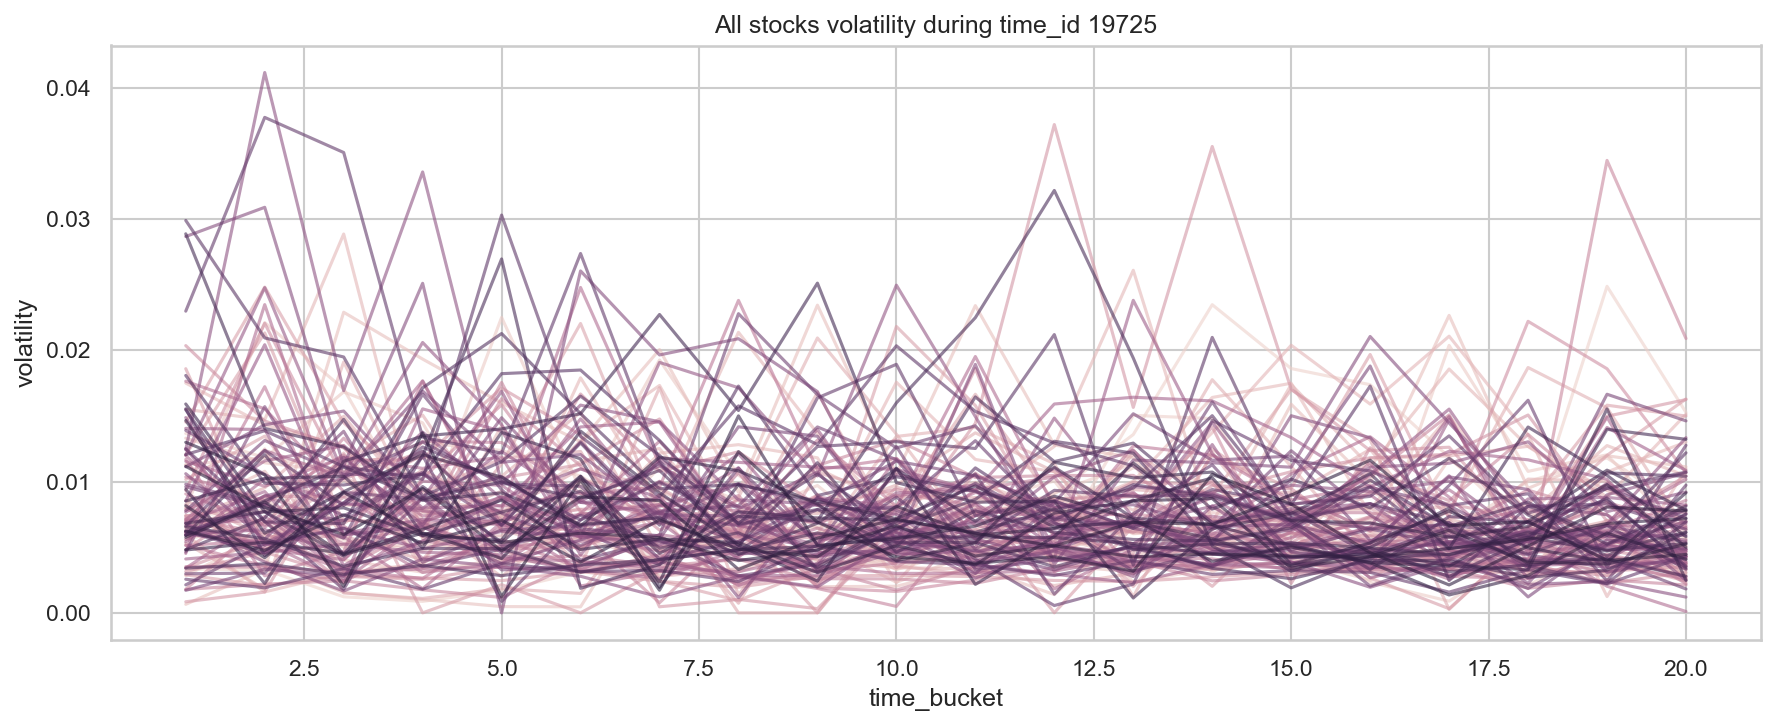

In [ ]:
turbulent = df[df['time_id'] == 19725]
# turbulent.head()
print(turbulent.groupby('stock_id')['volatility'].mean().describe())

# Plot volatility across buckets during that time_id
sns.lineplot(data=turbulent, x='time_bucket', y='volatility', 
             hue='stock_id', legend=False, alpha=0.6)
plt.title('All stocks volatility during time_id 19725')
plt.tight_layout()
plt.show()

In [ ]:
bucket0 = df[df['time_bucket'] == 0]
zero_starts = bucket0.groupby('time_id')['volatility'].max()
print(f"Time_ids where ALL stocks start at 0: {(zero_starts == 0).sum()}")
print(f"Total time_ids: {df['time_id'].nunique()}")

Time_ids where ALL stocks start at 0: 0
Total time_ids: 3830


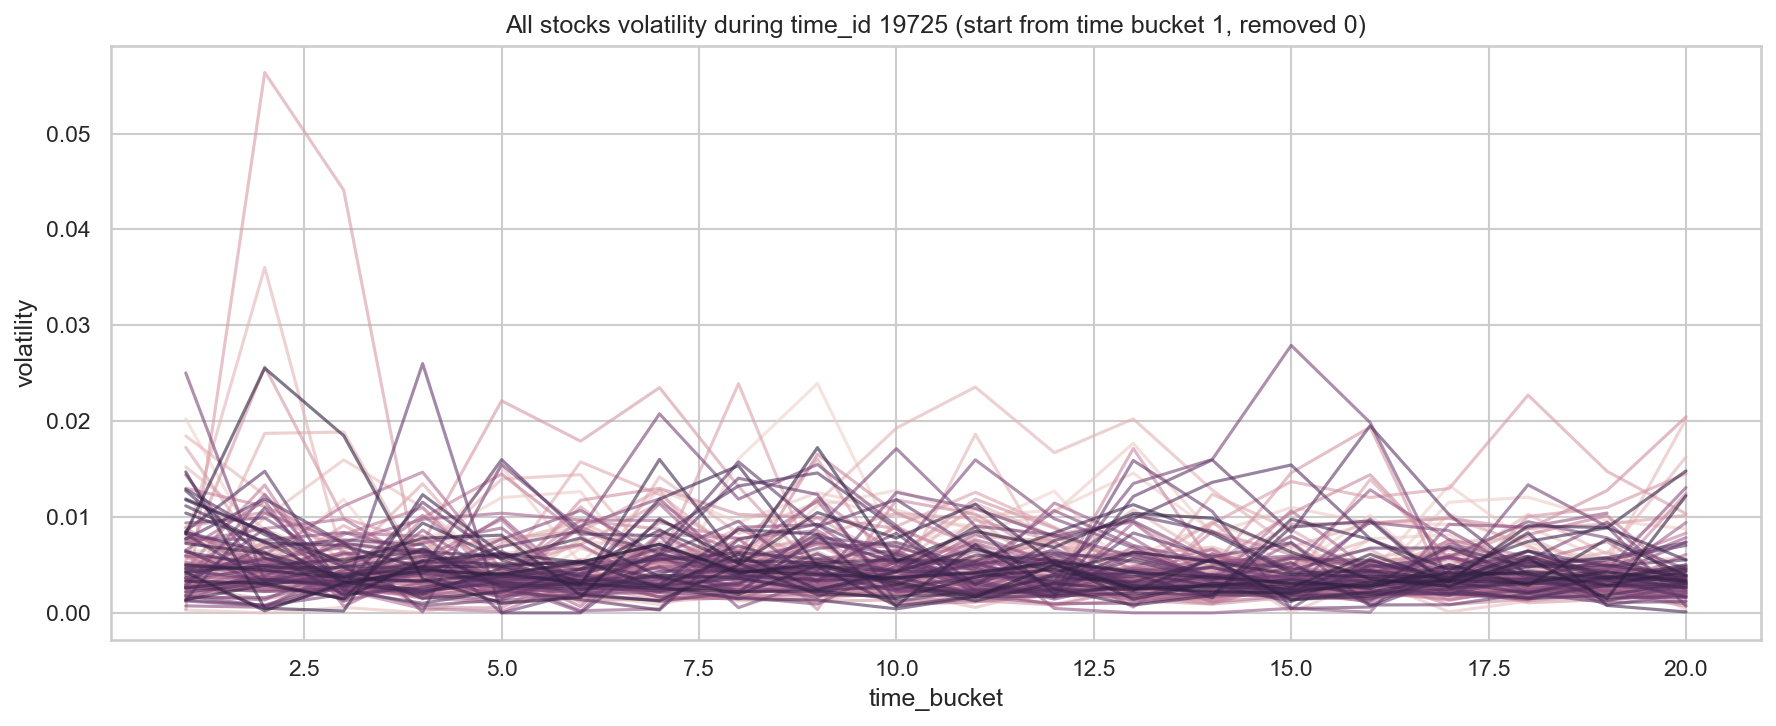

In [ ]:
turbulent = df[(df['time_id'] == 3138) & (df['time_bucket'] != 0)]

sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 5))
sns.lineplot(data=turbulent, x='time_bucket', y='volatility',
             hue='stock_id', legend=False, alpha=0.6)
plt.title('All stocks volatility during time_id 19725 (start from time bucket 1, removed 0)')
plt.tight_layout()

plt.show()

In [ ]:
df.head()

,stock_id,time_id,time_bucket,WAP_mean,BidAskSpread_mean,volatility
0,0,5,1.0,1.001590,0.000952,0.001057
1,0,5,2.0,1.002907,0.000734,0.001266
2,0,5,3.0,1.003727,0.000876,0.001090
3,0,5,4.0,1.004051,0.000873,0.000367
4,0,5,5.0,1.004322,0.000718,0.001339


In [ ]:
top_stocks = (df[(df['time_id'] == 3138) & (df['time_bucket'] > 0)]
              .groupby('stock_id')['volatility']
              .mean()
              .sort_values(ascending=False)
              .head(5))
              
print(top_stocks)

stock_id
30    0.013280
33    0.011871
90    0.010188
18    0.009870
16    0.009529
Name: volatility, dtype: float64
